# Data Preprocessing

In [2]:
# import something you may find useful
import os, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset
from torchvision import datasets, transforms, models
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# set seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# create a folder to save data
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

Device: cpu


In [3]:
#imaget_norm consist of the mean and std of imagenet dataset
imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# The following class will be used to preprocess our data
# Every image in our dataset will be resized to 224x224 and converted to tensors
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    imagenet_norm
])

# Data Augmentation on the train dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    imagenet_norm
])
    
    




## Loading the dataset

### Note: In the data split below, I merged the original train test val data into a single dataset, and then split them again using 60-20-20 rule. The original dataset didnot had enough observations in the validation set for me to validate the parameters.

In [4]:
batch_size = 64
# Load the original datasets
train_data_old = datasets.ImageFolder(root='./train', transform=transform)
val_data_old   = datasets.ImageFolder(root='./val', transform=transform)
test_data_old  = datasets.ImageFolder(root='./test', transform=transform)

# Merge them into one dataset
full_dataset = ConcatDataset([train_data_old, val_data_old, test_data_old])

In [5]:
total_len = len(full_dataset)
train_len = int(0.6 * total_len)
val_len = int(0.2 * total_len)
test_len = total_len - train_len - val_len

generator = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=generator
)
# Train dataset gets AUGMENTATION
train_data.dataset.transform = train_transform

# Val/test get ONLY resizing+normalization
val_data.dataset.transform = transform
test_data.dataset.transform = transform

batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [6]:
len(train_data), len(val_data), len(test_data)

(3513, 1171, 1172)

# Feature extraction and Baselines / Progress Report Code

## In the following section, instead of using a CNN for image classification, we will be extracting features from our images using a pre-trained model, and then performing traditional ML models such as SVM, LR, and FNN.

In [7]:
# Load pretrained model
# feature extractor will be used to extract features from our images
resnet = models.resnet18(pretrained=True)
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.eval() 

/Users/muneebhassan/Desktop/chest_xray/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/muneebhassan/Desktop/chest_xray/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [8]:
# Function to extract features
def extract_features(dataset):
    
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    features, labels = [], []
    with torch.no_grad():
        for images, y in loader:
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1)  
            features.append(outputs.numpy())
            labels.append(y.numpy())
    
    X = np.concatenate(features)
    y = np.concatenate(labels)
    return X, y

In [9]:
# Extract features for all sets
X_train, y_train = extract_features(train_data)
X_val, y_val = extract_features(test_data)
X_test, y_test = extract_features(val_data)

In [10]:
# Convet the dataset to pandas dataframe
import pandas as pd
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.DataFrame(y_train)
X_val_df = pd.DataFrame(X_val)
y_val_df = pd.DataFrame(y_val)
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)

In [11]:
# --- Majority Baseline ---
from collections import Counter

def predict_majority_baseline(y_train, X_test, X_val):

    # 1. Count the occurrences of each class
    counts = Counter(y_train)

    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)

    # 2. Determine the majority class
    # If counts are equal, we arbitrarily choose 1 (or 0, the choice doesn't matter for the baseline accuracy)
    if count_1 >= count_0:
        majority_class = 1
    else:
        majority_class = 0

    # 3. Generate predictions for the test set
    num_test_samples_test = len(X_test)
    num_test_samples_val = len(X_val)
    predictions_test = np.full(num_test_samples_test, majority_class)
    predictions_val = np.full(num_test_samples_val, majority_class)

    return pd.DataFrame(predictions_test), pd.DataFrame(predictions_val)

In [12]:
# --- Logistic Regression Baseline ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train
lr_model = LogisticRegression(max_iter=500, solver='lbfgs')
lr_model.fit(X_train_df, y_train_df)

# Evaluate on validation and test sets
for split, (X, y) in {
    "Validation": (X_val_df, y_val_df),
    "Test": (X_test_df, y_test_df)
}.items():
    preds = lr_model.predict(X)
    print(f"{split} Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"{split} Report:\n", classification_report(y, preds))



Validation Accuracy: 0.9616
Validation Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       329
           1       0.97      0.98      0.97       843

    accuracy                           0.96      1172
   macro avg       0.96      0.95      0.95      1172
weighted avg       0.96      0.96      0.96      1172

Test Accuracy: 0.9582
Test Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       319
           1       0.96      0.98      0.97       852

    accuracy                           0.96      1171
   macro avg       0.95      0.94      0.95      1171
weighted avg       0.96      0.96      0.96      1171



/Users/muneebhassan/Desktop/chest_xray/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
# --- Support Vector Machine ---
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train_df, y_train_df)

svm_preds = svm_model.predict(X_test_df)
print(classification_report(y_test_df, svm_preds))


/Users/muneebhassan/Desktop/chest_xray/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       0.94      0.90      0.92       319
           1       0.96      0.98      0.97       852

    accuracy                           0.96      1171
   macro avg       0.95      0.94      0.94      1171
weighted avg       0.96      0.96      0.96      1171



In [14]:
import torch
from torch import nn, optim

input_size = X_train_df.shape[1]
model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train_df.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_df.values.reshape(-1, 1), dtype=torch.float32)

for epoch in range(10):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/10, Loss: {loss.item():.4f}")


X_test_tensor = torch.tensor(X_test_df.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_df.values.reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = (y_pred_tensor.numpy() > 0.5).astype(int)  # convert probabilities → class labels

# Classification report & accuracy
print("FNN Test Accuracy:", accuracy_score(y_test_df, y_pred))
print(classification_report(y_test_df, y_pred))


Epoch 1/10, Loss: 0.7845
Epoch 2/10, Loss: 0.6005
Epoch 3/10, Loss: 0.6023
Epoch 4/10, Loss: 0.5766
Epoch 5/10, Loss: 0.5323
Epoch 6/10, Loss: 0.4938
Epoch 7/10, Loss: 0.4668
Epoch 8/10, Loss: 0.4441
Epoch 9/10, Loss: 0.4186
Epoch 10/10, Loss: 0.3911
FNN Test Accuracy: 0.8761742100768574
              precision    recall  f1-score   support

           0       0.92      0.60      0.72       319
           1       0.87      0.98      0.92       852

    accuracy                           0.88      1171
   macro avg       0.89      0.79      0.82      1171
weighted avg       0.88      0.88      0.87      1171



Dataset Info:
Total Samples: 5856
Train Samples: 3513
Validation Samples: 1172
Test Samples: 1171
Feature Count: 512
Class Distribution: {'No Pneumonia (0)': 1583, 'Pneumonia (1)': 4273}
Model Performance Summary:


,Model,Validation Accuracy,Test Accuracy,F1 Score (Test)
0,Majority Baseline,0.2807,0.2724,0.0000
1,Logistic Regression,0.9616,0.9582,0.9715
2,SVM (RBF Kernel),0.9642,0.9564,0.9703
3,Feedforward NN (PyTorch),0.8635,0.8762,0.9201


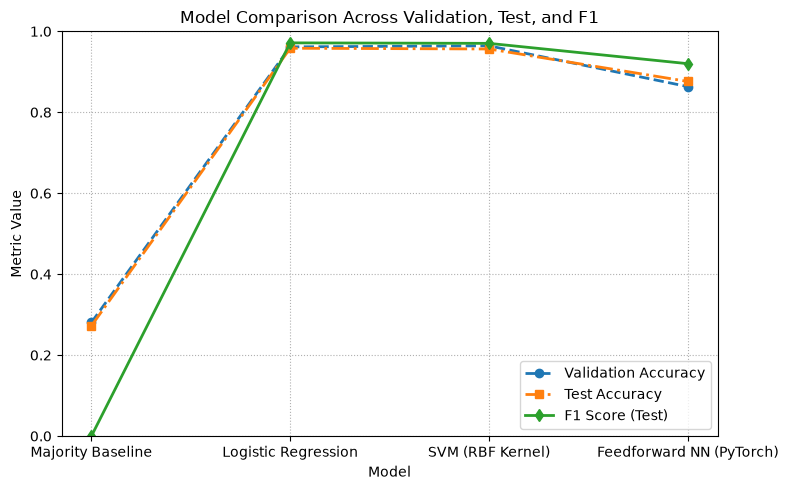

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import torch

dataset_info = {
    "Total Samples": len(X_train_df) + len(X_val_df) + len(X_test_df),
    "Train Samples": len(X_train_df),
    "Validation Samples": len(X_val_df),
    "Test Samples": len(X_test_df),
    "Feature Count": X_train_df.shape[1],
    "Class Distribution": {
        "No Pneumonia (0)": int((y_train_df == 0).values.sum() + (y_val_df == 0).values.sum() + (y_test_df == 0).values.sum()),
        "Pneumonia (1)": int((y_train_df == 1).values.sum() + (y_val_df == 1).values.sum() + (y_test_df == 1).values.sum())
    }
}

metrics = {}
# Majority Baseline
mb_test_preds, mb_val_preds = predict_majority_baseline(y_train_df, X_test_df, X_val_df)
metrics["Majority Baseline"] = {
    "Validation Accuracy": accuracy_score(y_val_df, mb_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, mb_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, mb_test_preds)
}


# Logistic Regression
lr_val_preds = lr_model.predict(X_val_df)
lr_test_preds = lr_model.predict(X_test_df)
metrics["Logistic Regression"] = {
    "Validation Accuracy": accuracy_score(y_val_df, lr_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, lr_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, lr_test_preds)
}

# SVM
svm_val_preds = svm_model.predict(X_val_df)
svm_test_preds = svm_model.predict(X_test_df)
metrics["SVM (RBF Kernel)"] = {
    "Validation Accuracy": accuracy_score(y_val_df, svm_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, svm_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, svm_test_preds)
}

# FNN (PyTorch)
with torch.no_grad():
    fnn_val_preds = (model(torch.tensor(X_val_df.values, dtype=torch.float32)).numpy() > 0.5).astype(int)
    fnn_test_preds = (model(torch.tensor(X_test_df.values, dtype=torch.float32)).numpy() > 0.5).astype(int)

metrics["Feedforward NN (PyTorch)"] = {
    "Validation Accuracy": accuracy_score(y_val_df, fnn_val_preds),
    "Test Accuracy": accuracy_score(y_test_df, fnn_test_preds),
    "F1 Score (Test)": f1_score(y_test_df, fnn_test_preds)
}

results_df = pd.DataFrame(metrics).T.reset_index().rename(columns={"index": "Model"}).round(4)


print("Dataset Info:")
for k, v in dataset_info.items():
    print(f"{k}: {v}")

print("Model Performance Summary:")
display(results_df)

models = results_df['Model']

plt.figure(figsize=(8,5))
plt.plot(models, results_df['Validation Accuracy'], 'o--', linewidth=2, label='Validation Accuracy')
plt.plot(models, results_df['Test Accuracy'], 's-.', linewidth=2, label='Test Accuracy')
plt.plot(models, results_df['F1 Score (Test)'], 'd-', linewidth=2, label='F1 Score (Test)')

plt.title('Model Comparison Across Validation, Test, and F1')
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.ylim(0, 1)
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()
